<a href="https://colab.research.google.com/github/JosephNathaniel/ARENA/blob/main/chapter1_transformer_interp/exercises/part2_intro_to_mech_interp/induction-heads-rigorously.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports and setup

In [65]:
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import math
import einops
import matplotlib.pyplot as plt
import random
import numpy as np

from jaxtyping import Float, Int

# from plotly_utils import hist, imshow, plot_comp_scores, plot_logit_attribution, plot_loss_difference


In [7]:
DEVICE = "cuda" if t.cuda.is_available() else "cpu"

In [10]:
# Function for generating repeated sequence dataset

def generate_repeated_tokens(
    vocab_size, seq_len: int, batch_size: int = 1, unique = False
) -> t.Tensor: # batch_size 2*seq_len
    """
    Generates a sequence of repeated random tokens

    Outputs are:
        rep_tokens: [batch_size, 1+2*seq_len]
    """
    if unique == True:
        assert vocab_size >= seq_len, "If unique, vocab_size must be >= seq_len"
        rand_seqs = [random.sample(range(vocab_size), k=seq_len) for _ in range(batch_size)]
        rand_seqs = t.tensor(rand_seqs, device=DEVICE)
    else:
        rand_seqs = t.randint(low=0, high=vocab_size, size=(batch_size, seq_len)).to(DEVICE)

    return_tensor = t.concat([rand_seqs, rand_seqs], dim=1)
    return return_tensor

# Part 1 -- a minimal, analytic induction head

Note -- two lessons from below.
Softmax occurs in the attention mechanism as well as to decode the output logits.
One-hots that go through softmaxes are no longer 'peaky'. Hence, in the attention and output, we must use a big scaling factor, to get the desired peaky distribution after the softmax.

## Model

In [ ]:
class AttentionBlock(nn.Module):
    """
    A single attention block according to the specified constraints:
    - 1 head
    - d_head = d_model
    - No MLP block
    - No LayerNorm
    - Positional embeddings added to Q and K inputs, not the residual stream.
    """
    def __init__(self, d_model: int, max_seq_len: int):
        super().__init__()
        self.d_model = d_model
        # Since num_heads = 1 and d_head = d_model, these are square matrices
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        # Scale factor for attention
        self.scale = d_model ** -0.5


    def forward(self, x: t.Tensor, pos_emb: t.Tensor, mask: t.Tensor | None = None) -> t.Tensor:
        """
        Forward pass for the Attention Block.

        Args:
            x: Input tensor (residual stream). Shape: (batch_size, seq_len, d_model)
            pos_emb: Positional embeddings. Shape: (1, seq_len, d_model) or (batch_size, seq_len, d_model)
            mask: Optional attention mask. Shape: (batch_size, seq_len, seq_len) or similar broadcastable.
                  Positions with `False` or `0` will be masked out.

        Returns:
            Output tensor after attention and output projection. Shape: (batch_size, seq_len, d_model)
        """
        batch_size, seq_len, _ = x.shape

        # 1. Add positional embeddings *before* Q and K projections
        #    Value stream does not get positional embeddings.
        qk_input = x + pos_emb
        v_input = x # V uses the original residual stream state

        # 2. Project inputs to Q, K, V
        Q = self.W_q(qk_input) # Shape: (batch_size, seq_len, d_model)
        K = self.W_k(qk_input) # Shape: (batch_size, seq_len, d_model)
        V = self.W_v(v_input) # Shape: (batch_size, seq_len, d_model)

        # 3. Calculate scaled dot-product attention scores
        # (batch, seq_len, d_model) @ (batch, d_model, seq_len) -> (batch, seq_len, seq_len)
        attn_scores = einops.einsum(Q, K, "b sq d, b sk d -> b sq sk") * self.scale

        # 4. Apply attention mask (if provided)
        if mask is not None:
            if mask.dim() == 3:
                 mask = mask[:,:seq_len, :seq_len] # this will deal with overly-large causal mask
            else:
                 raise NotImplementedError

            # Masked positions (False) are filled with a large negative value
            attn_scores = attn_scores.masked_fill(mask == False, -1e9) # Use a large negative number

        # 5. Apply softmax to get attention probabilities
        attn_probs = F.softmax(attn_scores, dim=-1) # Shape: (batch_size, seq_len, seq_len)

        # 6. Calculate weighted sum of Values
        # (batch, seq_len, seq_len) @ (batch, seq_len, d_model) -> (batch, seq_len, d_model)
        attn_output = einops.einsum(attn_probs, V, "b sq sk, b sk d -> b sq d")

        # 7. Apply output projection
        output = self.W_o(attn_output) # Shape: (batch_size, seq_len, d_model)

        return output


class SimpleTransformer(nn.Module):
    """
    A simple 2-layer, attention-only Transformer with a specific positional embedding handling.
    """
    def __init__(self, vocab_size: int, d_model: int, num_layers: int, max_seq_len: int):
        super().__init__()
        assert num_layers == 2, "This specific implementation is hardcoded for num_layers=2"
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # Token Embedding layer
        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # Positional Embedding layer (will be added before Q and K, not to residual stream directly)
        self.positional_embedding = nn.Embedding(max_seq_len, d_model)

        # Stack of Attention Blocks
        self.layers = nn.ModuleList([AttentionBlock(d_model, max_seq_len) for _ in range(num_layers)])

        # Final linear layer to map back to vocabulary size (optional, for tasks like LM)
        self.unembed = nn.Linear(d_model, vocab_size, bias=False)

        # Create maximally sized causal mask. Shape (1, max_seq_len, max_seq_len)
        # False is masked, True is unmasked
        self.maximal_causal_mask = t.tril(t.ones(1,max_seq_len, max_seq_len)).bool()

    def forward(self, input_ids: t.Tensor, attention_mask: t.Tensor | None = None) -> t.Tensor:
        """
        Forward pass for the Simple Transformer.

        Args:
            input_ids: Input token IDs. Shape: (batch_size, seq_len)
            attention_mask: Optional mask to prevent attention to certain positions (e.g., padding).
                            Positions that are True are kept, False are masked.
                            Can handle overly large masks, various number of dimensions...
                            Will be converted to the appropriate shape for attention scores.

        Returns:
            Logits tensor. Shape: (batch_size, seq_len, vocab_size)
        """
        batch_size, seq_len = input_ids.shape
        if seq_len > self.max_seq_len:
             raise ValueError(f"Input sequence length ({seq_len}) exceeds model's max sequence length ({self.max_seq_len})")


        # 1. Get Token Embeddings
        token_emb = self.token_embedding(input_ids) # Shape: (batch_size, seq_len, d_model)

        # 2. Get Positional Embeddings
        # Create position IDs (0, 1, 2, ..., seq_len-1)
        position_ids = t.arange(0, seq_len, device=input_ids.device).unsqueeze(0) # Shape: (1, seq_len)
        pos_emb = self.positional_embedding(position_ids) # Shape: (1, seq_len, d_model)
        # pos_emb will broadcast correctly to (batch_size, seq_len, d_model) when added

        # Initial residual stream is just the token embeddings
        residual_stream = token_emb

        for layer in self.layers:
            # Pass the current residual stream and the *same* positional embeddings each time
            attn_output = layer(residual_stream, pos_emb, mask=attention_mask)
            # Add the output of the attention block back to the residual stream
            residual_stream = residual_stream + attn_output

        # 5. Final unembedding layer (optional)
        logits = self.unembed(residual_stream) # Shape: (batch_size, seq_len, vocab_size)

        return logits

## Example Usage

In [ ]:
# Configuration
VOCAB_SIZE = 20
D_MODEL = 128
NUM_LAYERS = 2 # As requested
MAX_SEQ_LEN = 64
BATCH_SIZE = 4
DEVICE = "cuda" if t.cuda.is_available() else "cpu"

In [ ]:
test_sequences = generate_repeated_tokens(VOCAB_SIZE, 20, BATCH_SIZE)
print(test_sequences)

tensor([[ 7,  2,  8,  7, 18,  8,  0,  3, 13,  1,  1,  0,  2,  9, 12,  4,  0, 13,
         15, 11,  7,  2,  8,  7, 18,  8,  0,  3, 13,  1,  1,  0,  2,  9, 12,  4,
          0, 13, 15, 11],
        [13,  6, 18,  2,  3,  3, 12, 11, 16,  1, 19,  3,  1,  4,  4,  7,  9, 10,
         15,  7, 13,  6, 18,  2,  3,  3, 12, 11, 16,  1, 19,  3,  1,  4,  4,  7,
          9, 10, 15,  7],
        [ 9,  3, 14, 10, 11,  8,  6,  9,  4,  4,  4, 11, 14, 19, 13,  8, 18,  2,
          1,  8,  9,  3, 14, 10, 11,  8,  6,  9,  4,  4,  4, 11, 14, 19, 13,  8,
         18,  2,  1,  8],
        [17, 15, 18, 13,  6,  5, 12,  8, 11, 10, 13,  3, 15,  0,  2, 14, 16,  4,
         16,  0, 17, 15, 18, 13,  6,  5, 12,  8, 11, 10, 13,  3, 15,  0,  2, 14,
         16,  4, 16,  0]])


In [ ]:
# Instantiate the model
model = SimpleTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN
)
model.to(DEVICE)

print(f"Model:\n{model}")
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {num_params:,}")

Model:
SimpleTransformer(
  (token_embedding): Embedding(20, 128)
  (positional_embedding): Embedding(64, 128)
  (layers): ModuleList(
    (0-1): 2 x AttentionBlock(
      (W_q): Linear(in_features=128, out_features=128, bias=False)
      (W_k): Linear(in_features=128, out_features=128, bias=False)
      (W_v): Linear(in_features=128, out_features=128, bias=False)
      (W_o): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (unembed): Linear(in_features=128, out_features=20, bias=False)
)

Total trainable parameters: 144,384


In [ ]:
# Perform a forward pass
try:
    with t.no_grad(): # Disable gradient calculations for inference
        output_logits = model(test_sequences, attention_mask=model.maximal_causal_mask)

    print(f"\nInput shape: {test_sequences.shape}")
    print(f"Attention mask shape: {model.maximal_causal_mask.shape}")
    print(f"Output logits shape: {output_logits.shape}")
    print("\nForward pass successful!")

    # Verify masking (optional check)
    # Create a fully masked input and check if output changes significantly for masked parts
    masked_input = t.randint(0, VOCAB_SIZE, (1, MAX_SEQ_LEN))
    full_mask = t.zeros(1, MAX_SEQ_LEN, MAX_SEQ_LEN)
    out_fully_masked = model(masked_input, attention_mask=full_mask)
    out_no_mask = model(masked_input, attention_mask=t.ones(1,MAX_SEQ_LEN,MAX_SEQ_LEN))
    # This is a basic check; rigorous checks would involve inspecting attention scores.
    print(f"Output norm with no mask: {t.norm(out_no_mask)}")
    print(f"Output norm with full mask: {t.norm(out_fully_masked)} (should be similar if initial embedding dominates)")

except Exception as e:
    print(f"\nAn error occurred during forward pass: {e}")
    import traceback
    traceback.print_exc()


# Example with sequence length exceeding max_seq_len
print("\nTesting sequence length > max_seq_len:")
long_input_ids = t.randint(0, VOCAB_SIZE, (BATCH_SIZE, MAX_SEQ_LEN + 1))
try:
      with t.no_grad():
          output_logits = model(long_input_ids)
except ValueError as e:
      print(f"Caught expected error: {e}")


Input shape: torch.Size([4, 40])
Attention mask shape: torch.Size([1, 64, 64])
Output logits shape: torch.Size([4, 40, 20])

Forward pass successful!
Output norm with no mask: 20.791494369506836
Output norm with full mask: 20.720806121826172 (should be similar if initial embedding dominates)

Testing sequence length > max_seq_len:
Caught expected error: Input sequence length (65) exceeds model's max sequence length (64)


## Training

Let's play with it a bit to see that it's working

In [ ]:
# train on repeated sequences of length 20 (so, contexts of length 40)
train_sequences = generate_repeated_tokens(model.vocab_size, 20, 1024)

In [ ]:
# Training hyperparameters
LEARNING_RATE = 1e-3
EPOCHS = 50
BATCH_SIZE = 32  # You might need to adjust this based on your available memory

In [ ]:
# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = t.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
for epoch in range(EPOCHS):
    model.train()  # Set the model to training mode
    total_loss = 0

    for batch_idx in range(0, len(train_sequences), BATCH_SIZE):
        # Get a batch of data
        input_ids = train_sequences[batch_idx : batch_idx + BATCH_SIZE]
        targets = train_sequences[batch_idx : batch_idx + BATCH_SIZE, 1:]  # Shifted by one for next-token prediction

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids, attention_mask=model.maximal_causal_mask)
        logits = logits[:, :-1]  # Remove last token from logits

        # Calculate the loss
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_sequences)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

print("Training finished!")

Epoch 1/50, Loss: 0.0895
Epoch 2/50, Loss: 0.0531
Epoch 3/50, Loss: 0.0478
Epoch 4/50, Loss: 0.0469
Epoch 5/50, Loss: 0.0465
Epoch 6/50, Loss: 0.0462
Epoch 7/50, Loss: 0.0460
Epoch 8/50, Loss: 0.0458
Epoch 9/50, Loss: 0.0457
Epoch 10/50, Loss: 0.0455
Epoch 11/50, Loss: 0.0454
Epoch 12/50, Loss: 0.0453
Epoch 13/50, Loss: 0.0452
Epoch 14/50, Loss: 0.0451
Epoch 15/50, Loss: 0.0450
Epoch 16/50, Loss: 0.0450
Epoch 17/50, Loss: 0.0449
Epoch 18/50, Loss: 0.0448
Epoch 19/50, Loss: 0.0448
Epoch 20/50, Loss: 0.0447
Epoch 21/50, Loss: 0.0446
Epoch 22/50, Loss: 0.0446
Epoch 23/50, Loss: 0.0445
Epoch 24/50, Loss: 0.0445
Epoch 25/50, Loss: 0.0444
Epoch 26/50, Loss: 0.0444
Epoch 27/50, Loss: 0.0443
Epoch 28/50, Loss: 0.0443
Epoch 29/50, Loss: 0.0442
Epoch 30/50, Loss: 0.0442
Epoch 31/50, Loss: 0.0441
Epoch 32/50, Loss: 0.0441
Epoch 33/50, Loss: 0.0440
Epoch 34/50, Loss: 0.0440
Epoch 35/50, Loss: 0.0440
Epoch 36/50, Loss: 0.0439
Epoch 37/50, Loss: 0.0439
Epoch 38/50, Loss: 0.0439
Epoch 39/50, Loss: 0.

## Testing

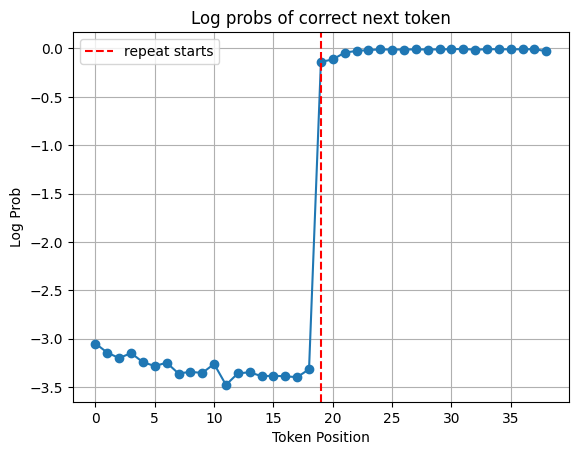

In [ ]:
# look at how well it generalizes to unseen length-20 random sequences
test_seq_len = 20

# generate test data
test_sequences = generate_repeated_tokens(model.vocab_size, test_seq_len, 1024)


# run model on test data
with t.no_grad():
    output_logits = model(test_sequences, attention_mask=model.maximal_causal_mask)

# Get correct next-token indices
target_ids = test_sequences[:, 1:]  # shape: (batch, 2*seq_len - 1)
log_probs = t.log_softmax(output_logits, dim=-1)
log_probs = log_probs[:, :-1]  # (batch, 2*seq_len-1, vocab_size)

# Gather log probs for correct token
correct_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1) # shape: (batch, 2*seq_len-1)

# average across batch
correct_log_probs_av = correct_log_probs.mean(dim=0)

# Plot
plt.plot(correct_log_probs_av.cpu().numpy(), marker='o')
plt.axvline(test_seq_len-1, color='red', linestyle='--', label='repeat starts')
plt.title("Log probs of correct next token")
plt.xlabel("Token Position")
plt.ylabel("Log Prob")
plt.legend()
plt.grid(True)
plt.show()


Nice, looks like it has learnt to do well on the second half of the sequence

For fun, let's see if it has learned to generalize to different lengths of sequences

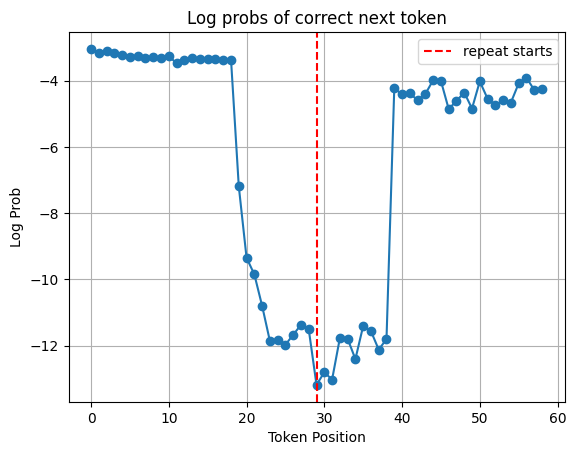

In [ ]:
# look at how well it generalizes to unseen length-20 random sequences
test_seq_len = 30

# generate test data
test_sequences = generate_repeated_tokens(model.vocab_size, test_seq_len, 1024)


# run model on test data
with t.no_grad():
    output_logits = model(test_sequences, attention_mask=model.maximal_causal_mask)

# Get correct next-token indices
target_ids = test_sequences[:, 1:]  # shape: (batch, 2*seq_len - 1)
log_probs = t.log_softmax(output_logits, dim=-1)
log_probs = log_probs[:, :-1]  # (batch, 2*seq_len-1, vocab_size)

# Gather log probs for correct token
correct_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1) # shape: (batch, 2*seq_len-1)

# average across batch
correct_log_probs_av = correct_log_probs.mean(dim=0)

# Plot
plt.plot(correct_log_probs_av.cpu().numpy(), marker='o')
plt.axvline(test_seq_len-1, color='red', linestyle='--', label='repeat starts')
plt.title("Log probs of correct next token")
plt.xlabel("Token Position")
plt.ylabel("Log Prob")
plt.legend()
plt.grid(True)
plt.show()


No, it has not generalized.
Explanation: the model was trained to repeat length 20 random sequences. So, after it sees the first 20, it tries to copy the initial sequence for tokens 20-40 ish, leading to the performance drop we see above

Then, apparently after the 40th token, it no longer knows what to do, so the error rate reverts to the baseline rate.

## Induction head transformer with manually set weights

In [ ]:
manual_model = SimpleTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN
)
manual_model.to(DEVICE)


SimpleTransformer(
  (token_embedding): Embedding(20, 128)
  (positional_embedding): Embedding(64, 128)
  (layers): ModuleList(
    (0-1): 2 x AttentionBlock(
      (W_q): Linear(in_features=128, out_features=128, bias=False)
      (W_k): Linear(in_features=128, out_features=128, bias=False)
      (W_v): Linear(in_features=128, out_features=128, bias=False)
      (W_o): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (unembed): Linear(in_features=128, out_features=20, bias=False)
)

In [ ]:
# we need a set of 3*VOCAB_SIZE + MAX_SEQ_LEN almost-orthogonal vectors
num_vectors = 3*VOCAB_SIZE + MAX_SEQ_LEN
print(num_vectors)

124


In [ ]:
# for now we just take one-hots
one_hots = t.eye(D_MODEL, device=DEVICE)[:,:num_vectors]
print(one_hots.shape) # d_model, num_vectors. I.e., the vectors are the columns

# we can shuffle (the columns) for good measure
one_hots = one_hots[:,t.randperm(one_hots.shape[1])]

emb_vectors, unemb_vectors, prev_token_space, pos_encs = t.split(one_hots, [20, 20, 20, 64], dim=1)

torch.Size([128, 124])


Now, we use these to generate 2 sets of W_q, W_k, W_v, W_o weights, as per our induction head construction

For the initial layer head, the constraints are the following:

* Firstly,
$$W_{qk}=\mu\sum_{i=1}^\text{MAX_SEQ_LEN}|p_{i}\rangle \langle p_{i-1}|$$
where $p_i$ are the positional encoding vectors.
$\mu$ is some large scaling constant, to make the attention peaky even after softmax.
This means that in the attention mechanism, the query at position $i$ matches with the key at position $i-1$.

We can set $W_q$ to be the identity times the constant $\mu$, and get $W_k$ to do the shifting. So $W_k=|p_1\rangle\langle p_0|+|p_2\rangle\langle p_1|+\ldots +|p_\text{MAX_SEQ_LEN}\rangle\langle p_{\text{MAX_SEQ_LEN}-1}|$

* Secondly,
$$W_{ov}=\sum_{z=1}^\text{VOCAB_SIZE}|w_z\rangle\langle v_z|$$
where $v_z$ are the embedding vectors, and $w_z$ are the previous token space vectors.
This means it takes the token embedding $v_z$ to the previous-token-embedding $w_z$.

We can set $W_v$ to be the identity, and $W_o$ to be the matrix.

In [ ]:
scale_factor = 1e6

In [ ]:
# ======= W_q, head 0 =======
W_q0 = scale_factor * t.eye(D_MODEL, device=DEVICE)

# ======= W_k, head 0 =======
# do an outer product with einops. Need to be careful with indexing here
W_k0 = einops.einsum(pos_encs[:,1:], pos_encs[:,:-1], "dmod seq, dmod2 seq -> dmod dmod2")

# verify
assert (W_k0 @ pos_encs[:,:-1] == pos_encs[:,1:]).all()

# ======= W_v, head 0 =======
W_v0 = t.eye(D_MODEL, device=DEVICE)

# ======= W_o, head 0 =======
W_o0 = einops.einsum(prev_token_space, emb_vectors, "dmod vocab, dmod2 vocab -> dmod dmod2")

For the final layer head, the constraints are the following:

* Firstly,
$$W_{qk} = \mu\sum_{z=1}^\text{VOCAB_SIZE} |v_z\rangle\langle w_z|$$
This means that the current token $v_z$ looks for $w_z$, i.e. it looks for the stream following an earlier $z$ token.

We can set $W_q$ to be the identity times $\mu$ and get $W_k$ to do the matching work.

* Secondly,
$$W_{ov} = \mu \sum_{z=1}^\text{VOCAB_SIZE}|u_z\rangle\langle v_z|$$
where $u_z$ is the pre-embedding activation for predicing $z$ as the next token.
This means the stream with token $z$ yields a next token prediction of $z$, if paid attention to.
Because the outputs are logits which are softmaxed, this also needs to be scaled by a large factor.

We can set $W_v$ to be the identity times $\mu$ and get $W_o$ to do the work.

In [ ]:
# ======= W_q, head 1 =======
W_q1 = scale_factor * t.eye(D_MODEL, device=DEVICE)

# ======= W_k, head 1 =======
W_k1 = einops.einsum(emb_vectors, prev_token_space, "dmod vocab, dmod2 vocab -> dmod dmod2")

# ======= W_v, head 1 =======
W_v1 = scale_factor * t.eye(D_MODEL, device=DEVICE)

# ======= W_o, head 1 =======
W_o1 = einops.einsum(unemb_vectors, emb_vectors, "dmod vocab, dmod2 vocab -> dmod dmod2")


In [ ]:
# now, insert all the weights into the model
assert manual_model.token_embedding.weight.data.shape == emb_vectors.T.shape
assert manual_model.positional_embedding.weight.data.shape == pos_encs.T.shape
assert manual_model.layers[0].W_q.weight.data.shape == W_q0.shape
assert manual_model.layers[0].W_k.weight.data.shape == W_k0.shape
assert manual_model.layers[0].W_v.weight.data.shape == W_v0.shape
assert manual_model.layers[0].W_o.weight.data.shape == W_o0.shape
assert manual_model.layers[1].W_q.weight.data.shape == W_q1.shape
assert manual_model.layers[1].W_k.weight.data.shape == W_k1.shape
assert manual_model.layers[1].W_v.weight.data.shape == W_v1.shape
assert manual_model.layers[1].W_o.weight.data.shape == W_o1.shape
assert manual_model.unembed.weight.data.shape == unemb_vectors.T.shape

with t.no_grad():
  manual_model.token_embedding.weight.data = emb_vectors.T
  manual_model.positional_embedding.weight.data = pos_encs.T
  manual_model.layers[0].W_q.weight.data = W_q0
  manual_model.layers[0].W_k.weight.data = W_k0
  manual_model.layers[0].W_v.weight.data = W_v0
  manual_model.layers[0].W_o.weight.data = W_o0
  manual_model.layers[1].W_q.weight.data = W_q1
  manual_model.layers[1].W_k.weight.data = W_k1
  manual_model.layers[1].W_v.weight.data = W_v1
  manual_model.layers[1].W_o.weight.data = W_o1
  manual_model.unembed.weight.data = unemb_vectors.T

### Testing the manual model

Okay, now lets test our model on repeat sequences

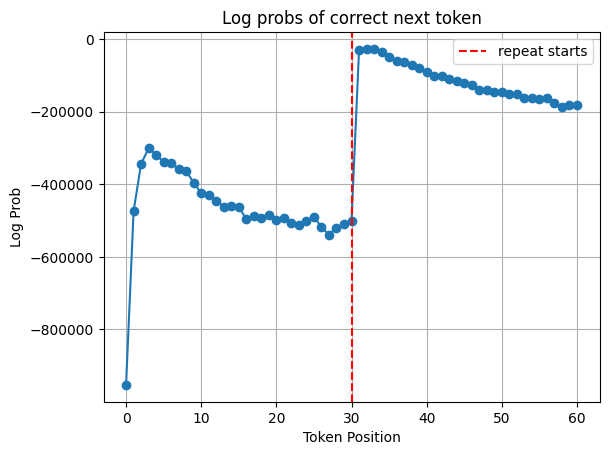

In [ ]:
test_seq_len = 31

# generate test data
test_sequences = generate_repeated_tokens(model.vocab_size, test_seq_len, 1024)


# run model on test data
with t.no_grad():
    output_logits = manual_model(test_sequences, attention_mask=model.maximal_causal_mask)

# Get correct next-token indices
target_ids = test_sequences[:, 1:]  # shape: (batch, 2*seq_len - 1)
log_probs = t.log_softmax(output_logits, dim=-1)
log_probs = log_probs[:, :-1]  # (batch, 2*seq_len-1, vocab_size)

# Gather log probs for correct token
correct_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1) # shape: (batch, 2*seq_len-1)

# average across batch
correct_log_probs_av = correct_log_probs.mean(dim=0)

# Plot
plt.plot(correct_log_probs_av.cpu().numpy(), marker='o')
plt.axvline(test_seq_len-1, color='red', linestyle='--', label='repeat starts')
plt.title("Log probs of correct next token")
plt.xlabel("Token Position")
plt.ylabel("Log Prob")
plt.legend()
plt.grid(True)
plt.show()


There's some of the expected behaviour going on, but it's far from perfect.

Now, the random sequences we use for testing may contain repeats, which could confuse the heads. My manual induction head construction was not designed to deal with this.
Let's try generate random sequences without repeating tokens and test the manual model on that instead.

In [ ]:
# e.g.
test_sequences[0]

tensor([10, 10, 11,  1,  8, 12,  9,  1,  2,  1,  1,  6,  6, 14,  5, 19,  5,  2,
         1, 16, 16, 15,  3,  7, 18, 15, 17,  9, 14,  3, 13, 10, 10, 11,  1,  8,
        12,  9,  1,  2,  1,  1,  6,  6, 14,  5, 19,  5,  2,  1, 16, 16, 15,  3,
         7, 18, 15, 17,  9, 14,  3, 13])

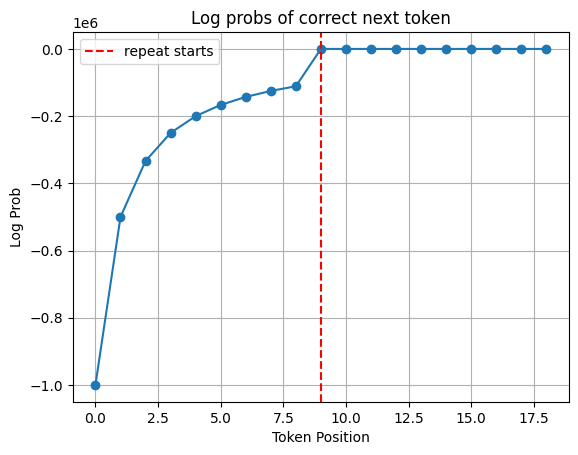

In [ ]:
test_seq_len = 10

# generate test data
test_sequences = generate_repeated_tokens(model.vocab_size, test_seq_len, 1024, unique=True) # Note the unique=True


# run model on test data
with t.no_grad():
    output_logits = manual_model(test_sequences, attention_mask=model.maximal_causal_mask)

# Get correct next-token indices
target_ids = test_sequences[:, 1:]  # shape: (batch, 2*seq_len - 1)
log_probs = t.log_softmax(output_logits, dim=-1)
log_probs = log_probs[:, :-1]  # (batch, 2*seq_len-1, vocab_size)

# Gather log probs for correct token
correct_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1) # shape: (batch, 2*seq_len-1)

# average across batch
correct_log_probs_av = correct_log_probs.mean(dim=0)

# Plot
plt.plot(correct_log_probs_av.cpu().numpy(), marker='o')
plt.axvline(test_seq_len-1, color='red', linestyle='--', label='repeat starts')
plt.title("Log probs of correct next token")
plt.xlabel("Token Position")
plt.ylabel("Log Prob")
plt.legend()
plt.grid(True)
plt.show()


Nice, it is now perfect on the second half of the sequence.

### Conclusion

The bad behaviour on the first test, with repeated tokens, confused the model. The performance in the second half was better, but still imperfect and degraded with time. So, to make that robust, seems like some extra construction is needed.

# Part 2 -- a more rigorous analysis of language model induction head

## More setup

In [2]:
import os
import sys
from pathlib import Path

import pkg_resources

IN_COLAB = "google.colab" in sys.modules

chapter = "chapter1_transformer_interp"
repo = "ARENA_3.0"
branch = "main"

# Install dependencies
installed_packages = [pkg.key for pkg in pkg_resources.working_set]
if "transformer-lens" not in installed_packages:
    %pip install transformer_lens==2.11.0 einops eindex-callum jaxtyping git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python

# Get root directory, handling 3 different cases: (1) Colab, (2) notebook not in ARENA repo, (3) notebook in ARENA repo
root = (
    "/content"
    if IN_COLAB
    else "/root"
    if repo not in os.getcwd()
    else str(next(p for p in Path.cwd().parents if p.name == repo))
)

if Path(root).exists() and not Path(f"{root}/{chapter}").exists():
    if not IN_COLAB:
        !sudo apt-get install unzip
        %pip install jupyter ipython --upgrade

    if not os.path.exists(f"{root}/{chapter}"):
        !wget -P {root} https://github.com/callummcdougall/ARENA_3.0/archive/refs/heads/{branch}.zip
        !unzip {root}/{branch}.zip '{repo}-{branch}/{chapter}/exercises/*' -d {root}
        !mv {root}/{repo}-{branch}/{chapter} {root}/{chapter}
        !rm {root}/{branch}.zip
        !rmdir {root}/ARENA_3.0-{branch}


if f"{root}/{chapter}/exercises" not in sys.path:
    sys.path.append(f"{root}/{chapter}/exercises")

os.chdir(f"{root}/{chapter}/exercises")

<ipython-input-2-ab5f983a7668>:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [3]:
from transformer_lens import (
    ActivationCache,
    FactoredMatrix,
    HookedTransformer,
    HookedTransformerConfig,
    utils,
)

## Load model

In [4]:
cfg = HookedTransformerConfig(
    d_model=768,
    d_head=64,
    n_heads=12,
    n_layers=2,
    n_ctx=2048,
    d_vocab=50278,
    attention_dir="causal",
    attn_only=True,  # defaults to False
    tokenizer_name="EleutherAI/gpt-neox-20b",
    seed=398,
    use_attn_result=True,
    normalization_type=None,  # defaults to "LN", i.e. layernorm with weights & biases
    positional_embedding_type="shortformer",
)

In [5]:
from huggingface_hub import hf_hub_download

REPO_ID = "callummcdougall/attn_only_2L_half"
FILENAME = "attn_only_2L_half.pth"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


attn_only_2L_half.pth:   0%|          | 0.00/184M [00:00<?, ?B/s]

In [8]:
model = HookedTransformer(cfg)
pretrained_weights = t.load(weights_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(pretrained_weights)

<All keys matched successfully>

In [9]:
# inspect the model
model.cfg

HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'act_fn': None,
 'attention_dir': 'causal',
 'attn_only': True,
 'attn_scale': 8.0,
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 64,
 'd_mlp': None,
 'd_model': 768,
 'd_vocab': 50278,
 'd_vocab_out': 50278,
 'decoder_start_token_id': None,
 'default_prepend_bos': True,
 'device': device(type='cpu'),
 'dtype': torch.float32,
 'eps': 1e-05,
 'experts_per_token': None,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': True,
 'initializer_range': 0.02886751345948129,
 'load_in_4bit': False,
 'model_name': 'custom',
 'n_ctx': 2048,
 'n_devices': 1,
 'n_heads': 12,
 'n_key_value_heads': None,
 'n_layers': 2,
 'n_params': 4718592,
 'normalization_type': None,
 'num_experts': None,
 'original_architectur

## Generate some activations from rep_tokens

In [56]:
rep_token_batch = generate_repeated_tokens(model.cfg.d_vocab, 50, batch_size = 1) # can adjust batch size here

rep_logits, rep_cache = model.run_with_cache(rep_token_batch)

print(rep_logits.shape) # batch_size, seq_len, d_vocab

torch.Size([1, 100, 50278])


In [57]:
rep_cache["result", 0].shape

torch.Size([1, 100, 12, 768])

In [58]:
model.cfg.d_model

768

## Final layer OV circuit

Final layer head V stream is a sum of 13 contributions -- 12 from the initial layer heads and the token embedding

We want to decompose the input into these 13 components and look at their effects on the final output logits

In [90]:
def decompose_layer_residual(cache: ActivationCache, layer: int) -> Float[t.Tensor, "n_heads+2 posn d_model"]:
    """
    Retrieves all the input tensors to the first attention layer, and concatenates them along the 0th dim.
    Note -- we want the cache tensors to include the batch dimension

    The [i, :, :]th element is y_i (from notation above). The sum of these tensors along the 0th dim should
    be the input to the first attention layer.
    """
    y0 = cache["embed"].unsqueeze(0)  # shape (1, batch, seq, d_model)
    y1 = cache["pos_embed"].unsqueeze(0)  # shape (1, batch, seq, d_model)
    y_rest = einops.rearrange(cache["result", layer], "batch seq heads d_model -> heads batch seq d_model")

    return t.concat([y1, y0, y_rest], dim=0) # shape: heads+2 batch seq d_model

We want to consider
$$x W^{1.4}_{OV} W_U$$
where
$$x=emb + x_{L0H1} + \ldots + x_{L0H12}$$

There are various ways we can compare the importance of these contributions.
We could look at e.g. the contribution to the correct logit, like in the logit lens. Or, we could look at just the norm of the logit. Both of these have some drawbacks...

Instead, lets look at the top-5 logits

In [92]:
# the OV doesn't get to see the positional embedding, so let's get rid of that
l1_ov_input = decompose_layer_residual(rep_cache, 0)[1:,:,:,:]

logits = einops.einsum(l1_ov_input, model.W_V[1, 4], model.W_O[1,4], model.W_U,
              "contrib batch seq d_model, d_model d_head, d_head d_model2, d_model2 d_vocab -> contrib batch seq d_vocab")

# look at top k logits for each contribution
# for now, mean over the batch
logits = einops.reduce(logits, "contrib batch seq d_vocab -> contrib seq d_vocab", "mean")
topk_vals, topk_idx = t.topk(logits, k=5, dim=-1)

In [93]:
topk_vals.shape

torch.Size([13, 100, 5])

In [94]:
top1_vals = topk_vals[:, :, 0]
top1_idx = topk_idx[:, :, 0]

In [95]:
top1_vals.shape

torch.Size([13, 100])

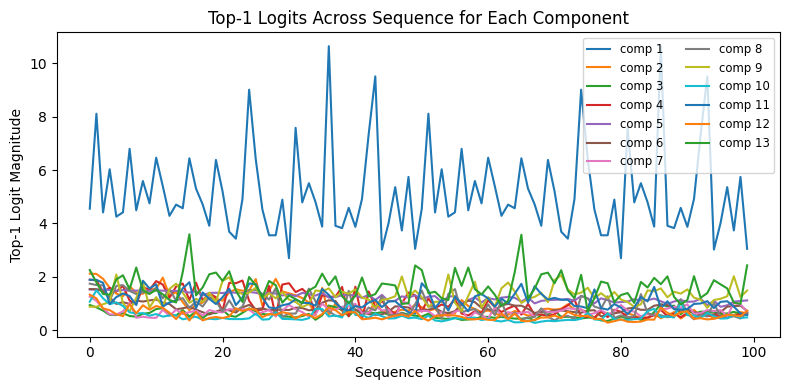

In [96]:
plot_data = top1_vals.detach().numpy()
n_components, seq_len = plot_data.shape
x = range(seq_len)

plt.figure(figsize=(8, 4))
for i in range(n_components):
    plt.plot(x, plot_data[i], label=f'comp {i+1}')
plt.xlabel('Sequence Position')
plt.ylabel('Top‑1 Logit Magnitude')
plt.title('Top‑1 Logits Across Sequence for Each Component')
plt.legend(loc='upper right', ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

Great! We see that component 1, corresponding to the token embeddings, gives a maximum logit score that dominates that of all the other components (coming from the 12 first layer heads)